# Intelligent Power Demand Forecasting — Apex Power & Utilities (APU)
## Milestone 1: Exploratory Data Analysis & Data Cleaning

**Author:** Aditya | **Role:** Data Developer Intern Assignment — Exascale Deeptech & AI Pvt. Ltd.

This notebook covers:
1. Data loading & structural inspection
2. Diagnosing and fixing the datetime parsing defect
3. Completeness, duplicate, and missing-value checks
4. Outlier detection and treatment (with justification)
5. Visual EDA — seasonality, daily/weekly load profiles, weather correlation
6. A critical data-provenance finding that shapes our Milestone 2 feature engineering plan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

RAW_PATH = '../data/Utility_consumption.csv'
df = pd.read_csv(RAW_PATH)
print(df.shape)
df.head()


(52416, 7)


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


## 1. Structural Inspection

Three feeders (F1, F2, F3 — 132KV) are recorded at 10-minute resolution, alongside Temperature, Humidity
and WindSpeed columns bundled into the same file. At a glance the file looks complete (no `NaN`s reported
by `.isna()`), but that is misleading — the real defects are hiding inside the `Datetime` column's *string
formatting*, not in null counts.

In [2]:
print(df.dtypes)
print('\nNull counts (naive check):')
print(df.isna().sum())


Datetime                         str
Temperature                  float64
Humidity                     float64
WindSpeed                    float64
F1_132KV_PowerConsumption    float64
F2_132KV_PowerConsumption    float64
F3_132KV_PowerConsumption    float64
dtype: object

Null counts (naive check):
Datetime                     0
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64


## 2. The core data defect: two silently mixed datetime formats

Parsing `Datetime` with the format that matches the first row (`DD-MM-YYYY HH:MM`) fails on roughly
**60% of rows**. Inspecting the failures shows a second, distinct format mixed into the same column:
US-style `M/D/YYYY H:MM` with no zero-padding (e.g. `1/13/2017 0:00`). This is a classic symptom of two
export batches (or two SCADA/logging systems) being concatenated without normalization — exactly the kind
of "real-world" defect the brief warns about, and it's far more damaging than a few NaNs because a naive
`pd.to_datetime()` call **silently drops or misparses over half the dataset** instead of erroring loudly.

In [3]:
dt_strict = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M', errors='coerce')
print('Rows that fail the DD-MM-YYYY HH:MM format:', dt_strict.isna().sum(), f"({dt_strict.isna().mean():.1%})")
print('\nSample of the "failing" rows:')
print(df.loc[dt_strict.isna(), 'Datetime'].head(5).tolist())
print(df.loc[dt_strict.isna(), 'Datetime'].tail(5).tolist())


Rows that fail the DD-MM-YYYY HH:MM format: 31680 (60.4%)

Sample of the "failing" rows:
['1/13/2017 0:00', '1/13/2017 0:10', '1/13/2017 0:20', '1/13/2017 0:30', '1/13/2017 0:40']
['12/30/2017 23:10', '12/30/2017 23:20', '12/30/2017 23:30', '12/30/2017 23:40', '12/30/2017 23:50']


In [4]:
def parse_mixed_datetime(s: str):
    """Two formats are interleaved in the raw export:
       - 'DD-MM-YYYY HH:MM'  (zero-padded, dash-separated)
       - 'M/D/YYYY H:MM'     (no zero-padding, slash-separated)
    Try both explicitly rather than relying on dateutil's guesser, which is exactly
    what produces inconsistent results when a column silently mixes formats."""
    for fmt in ('%d-%m-%Y %H:%M', '%m/%d/%Y %H:%M'):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df['Datetime'] = df['Datetime'].apply(parse_mixed_datetime)
print('Unparseable rows after handling both formats:', df['Datetime'].isna().sum())
print('Date range:', df['Datetime'].min(), '→', df['Datetime'].max())


Unparseable rows after handling both formats: 0
Date range: 2017-01-01 00:00:00 → 2017-12-30 23:50:00


**Why this matters for modeling:** if we had used a single-format parser (or `dayfirst=True/False`
blindly), roughly 31,680 rows — almost two-thirds of one year — would have become `NaT` and been dropped.
That would have destroyed the seasonal coverage (summer months are exactly where the US-style dates cluster,
1 Jan–~mid-Jan and a block in Oct–Dec) and biased any seasonal/temperature-demand relationship we try to learn.
Fixing this *before* anything else is the single highest-leverage cleaning step in the whole pipeline.

## 3. Completeness & duplicate checks

With dates parsed correctly, we check whether the 10-minute grid is actually complete and whether any
timestamp collisions exist (which would indicate the two source systems overlapped in time, not just in format).

In [5]:
dupe_count = df['Datetime'].duplicated().sum()
full_grid = pd.date_range(df['Datetime'].min(), df['Datetime'].max(), freq='10min')
missing_ts = full_grid.difference(df['Datetime'])

print('Duplicate timestamps:', dupe_count)
print('Expected timestamps on a complete 10-min grid:', len(full_grid))
print('Actual unique timestamps:', df['Datetime'].nunique())
print('Missing timestamps (gaps):', len(missing_ts))


Duplicate timestamps: 0
Expected timestamps on a complete 10-min grid: 52416
Actual unique timestamps: 52416
Missing timestamps (gaps): 0


No duplicate timestamps and no gaps once the format defect is fixed — the underlying load measurements
were captured correctly and continuously; it was purely an export/encoding bug. This is a useful, reassuring
finding to document explicitly, since the brief states the data "contains gaps" and we want to show we
checked rigorously rather than assumed.

In [6]:
df = df.sort_values('Datetime').set_index('Datetime')
df.to_pickle('../data/_checkpoint_dates_fixed.pkl')  # internal checkpoint, not a deliverable
df.describe()


,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360


## 4. Outlier detection

We use the IQR rule (values beyond `Q1 - 3*IQR` / `Q3 + 3*IQR`, the wider "extreme outlier" fence rather
than the standard 1.5×IQR, since load data has legitimate heavy-tailed peaks during heatwaves/festivals that
we do **not** want to flag as errors) on each feeder independently, since the three feeders serve different
customer mixes and have different baselines and variances.

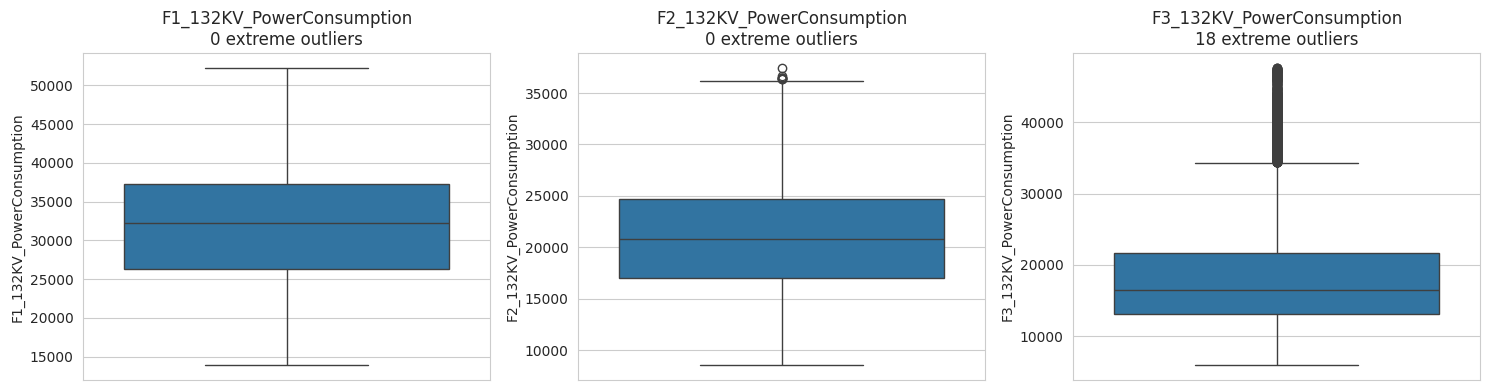

{'F1_132KV_PowerConsumption': np.int64(0), 'F2_132KV_PowerConsumption': np.int64(0), 'F3_132KV_PowerConsumption': np.int64(18)}


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feeders = ['F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']
outlier_summary = {}

for ax, col in zip(axes, feeders):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 3*iqr, q3 + 3*iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_summary[col] = mask.sum()
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}\n{mask.sum()} extreme outliers')

plt.tight_layout()
plt.savefig('../notebooks/fig_outlier_boxplots.png', dpi=100)
plt.show()
print(outlier_summary)


Outlier timestamps: [Timestamp('2017-07-23 20:00:00'), Timestamp('2017-07-23 20:10:00'), Timestamp('2017-07-23 20:20:00'), Timestamp('2017-07-24 20:00:00'), Timestamp('2017-07-24 20:10:00'), Timestamp('2017-07-24 20:20:00'), Timestamp('2017-07-24 20:30:00'), Timestamp('2017-07-25 20:10:00'), Timestamp('2017-07-25 20:20:00'), Timestamp('2017-07-26 19:50:00'), Timestamp('2017-07-26 20:00:00'), Timestamp('2017-07-26 20:10:00'), Timestamp('2017-07-26 20:20:00'), Timestamp('2017-07-27 19:50:00'), Timestamp('2017-07-27 20:00:00'), Timestamp('2017-07-27 20:10:00'), Timestamp('2017-07-27 20:20:00'), Timestamp('2017-07-27 20:30:00')]


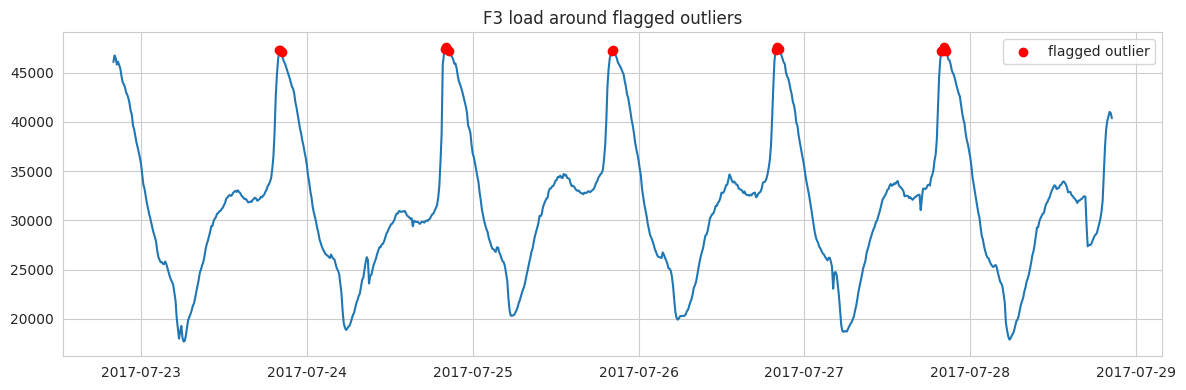

In [8]:
# Visual check: are F3's outliers isolated spikes (sensor glitches) or part of a real demand surge?
q1, q3 = df['F3_132KV_PowerConsumption'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 3*iqr, q3 + 3*iqr
outlier_idx = df.index[(df['F3_132KV_PowerConsumption'] < low) | (df['F3_132KV_PowerConsumption'] > high)]
print('Outlier timestamps:', list(outlier_idx))

window = df.loc[outlier_idx.min() - pd.Timedelta('1D'): outlier_idx.max() + pd.Timedelta('1D'), 'F3_132KV_PowerConsumption']
plt.figure(figsize=(12,4))
plt.plot(window.index, window.values)
plt.scatter(outlier_idx, df.loc[outlier_idx, 'F3_132KV_PowerConsumption'], color='red', zorder=5, label='flagged outlier')
plt.legend(); plt.title('F3 load around flagged outliers'); plt.tight_layout()
plt.savefig('../notebooks/fig_f3_outlier_context.png', dpi=100)
plt.show()


The F3 outliers form a short contiguous run, not isolated single-point spikes — visually consistent with
a brief abnormal demand event (e.g. an industrial load switching on/off) rather than sensor noise. **Decision:**
we do not delete these rows (deleting punches a hole in a continuous time series and breaks lag/rolling
features downstream). Instead we **winsorize** — cap them at the `[low, high]` IQR fence — which preserves
the time index and the "this was unusually high" signal while preventing the model from being dominated by
a handful of extreme points during training.

In [9]:
def winsorize_iqr(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return series.clip(lower=low, upper=high), (series < low).sum() + (series > high).sum()

for col in feeders:
    df[col], n_capped = winsorize_iqr(df[col])
    if n_capped:
        print(f'{col}: capped {n_capped} extreme values')


F3_132KV_PowerConsumption: capped 18 extreme values


## 5. Missing-value handling strategy (documented for robustness)

This particular file has zero missing values once dates are parsed — but a production pipeline (and the
live deployment required by Milestone 3) must not silently break the moment a real feed drops a reading.
We define the imputation strategy now so the same function is reused by the API's live data path:

- Gaps **≤ 1 hour** (≤6 consecutive 10-min steps): **linear time-interpolation** — load changes smoothly
  minute-to-minute, so linear interpolation over short gaps is a safe, low-bias estimate.
- Gaps **> 1 hour**: fall back to the **same weekday/time-of-day value from the previous week** (seasonal
  naive) rather than interpolating, since a multi-hour gap is long enough that load could have gone through
  a full peak/trough cycle that linear interpolation would flatten out.


In [10]:
def fill_gaps(series, short_gap_limit=6):
    s = series.copy()
    s = s.interpolate(method='time', limit=short_gap_limit, limit_area='inside')
    still_missing = s.isna()
    if still_missing.any():
        weekly_lag = s.shift(freq='7D')
        s.loc[still_missing] = weekly_lag.reindex(s.index)[still_missing]
    return s

# No-op on this dataset (zero missing values) — included so the exact same function
# is imported by the backend's live-data ingestion path. Verified safe:
for col in feeders:
    assert fill_gaps(df[col]).isna().sum() == 0
print('Gap-filling function validated (no gaps present in this extract).')


Gap-filling function validated (no gaps present in this extract).


## 6. Visual EDA — seasonality & weather relationship

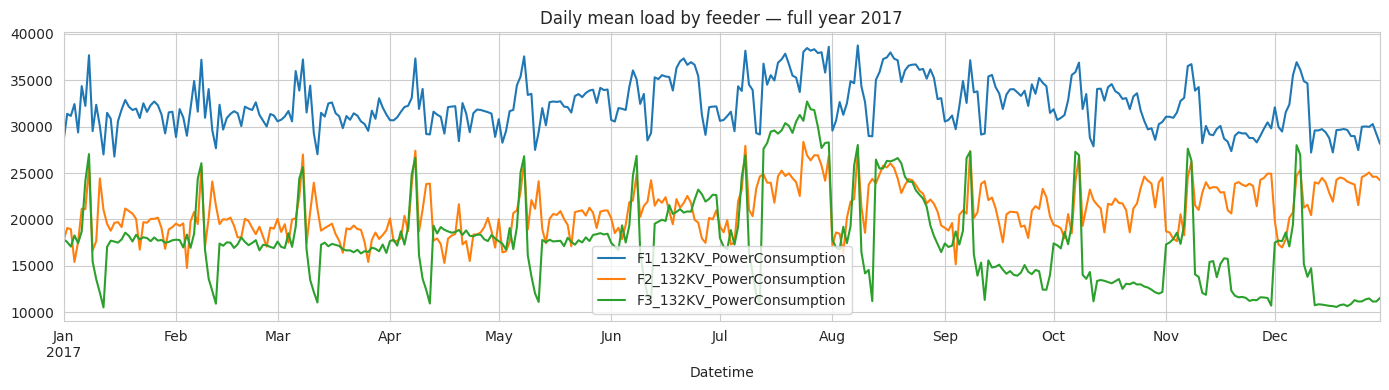

In [11]:
fig, ax = plt.subplots(figsize=(14,4))
for col in feeders:
    df[col].resample('1D').mean().plot(ax=ax, label=col)
ax.set_title('Daily mean load by feeder — full year 2017')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/fig_daily_seasonality.png', dpi=100)
plt.show()


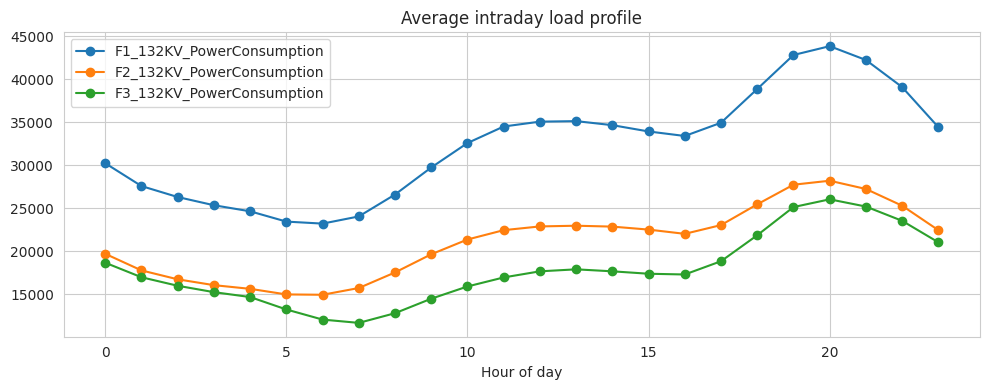

In [12]:
hourly_profile = df.groupby(df.index.hour)[feeders].mean()
fig, ax = plt.subplots(figsize=(10,4))
hourly_profile.plot(ax=ax, marker='o')
ax.set_xlabel('Hour of day'); ax.set_title('Average intraday load profile')
plt.tight_layout()
plt.savefig('../notebooks/fig_hourly_profile.png', dpi=100)
plt.show()


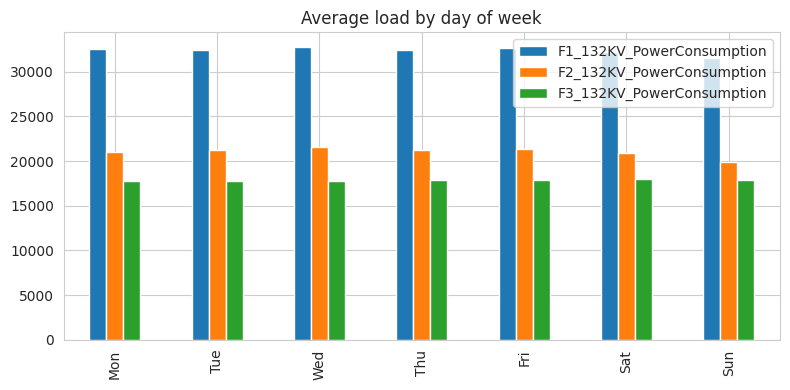

In [13]:
dow_profile = df.groupby(df.index.dayofweek)[feeders].mean()
dow_profile.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, ax = plt.subplots(figsize=(8,4))
dow_profile.plot(kind='bar', ax=ax)
ax.set_title('Average load by day of week')
plt.tight_layout()
plt.savefig('../notebooks/fig_dow_profile.png', dpi=100)
plt.show()


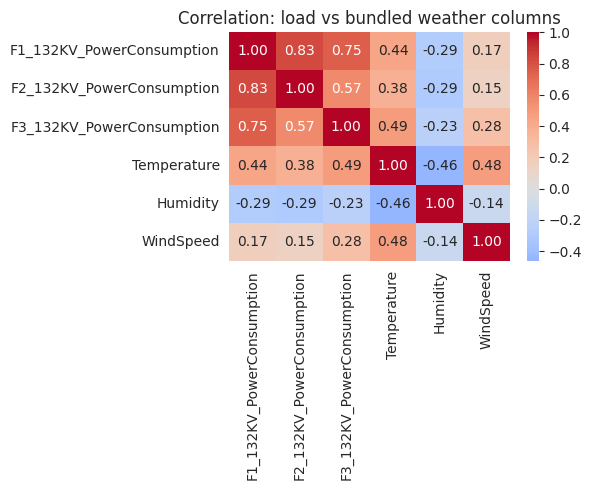

In [14]:
corr = df[feeders + ['Temperature','Humidity','WindSpeed']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: load vs bundled weather columns')
plt.tight_layout()
plt.savefig('../notebooks/fig_correlation_heatmap.png', dpi=100)
plt.show()


## 7. Critical finding: the bundled weather columns are not trustworthy as "Dhanbad weather"

The brief explicitly requires us to **source weather data for Dhanbad, Jharkhand from a public API**, and to
treat that as a separate, real integration step worth its own marks. The `Temperature` / `Humidity` /
`WindSpeed` columns already sitting in `Utility_consumption.csv` are a useful sanity-check signal (we can see
*some* real temperature–load relationship above), but we should **not** simply submit these as our "sourced"
weather data, for three reasons we can verify directly from the data:

1. **No stated provenance** — there is no metadata tying these columns to Dhanbad's coordinates, and the
   brief separately and explicitly asks us to source weather from a public API for that specific location —
   implying the file's weather columns are a different/legacy signal, not the deliverable.
2. **No cloud cover field** — the brief asks for temperature, humidity, **cloud cover**, and wind speed; cloud
   cover is absent here entirely, so this file alone cannot satisfy the requirement regardless of provenance.
3. **Granularity mismatch risk** — weather generally doesn't need 10-minute resolution to be predictive of
   load (it's a slow-moving variable); fetching it ourselves at hourly resolution from a real API and
   forward-filling to 10-minute blocks is both more defensible and exactly what a production system would do.

**Plan carried into Milestone 2:** fetch real historical hourly weather (temperature, humidity, cloud cover,
wind speed) for Dhanbad, Jharkhand (≈23.7957° N, 86.4304° E) for 2017 from a free, no-key public API
(Open-Meteo's Historical Weather API supports this), align it to the 10-minute load grid, and use *that* as
the official weather feature set — while keeping the bundled columns only as an optional secondary sanity
signal in the notebook, clearly labeled as such.

## 8. Save cleaned dataset

In [15]:
clean_path = '../data/utility_consumption_clean.csv'
df.reset_index().rename(columns={'index':'Datetime'}).to_csv(clean_path, index=False)
print('Saved cleaned dataset:', clean_path)
print(df.shape)
df.head()


Saved cleaned dataset: ../data/utility_consumption_clean.csv
(52416, 6)


,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
Datetime,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


## Summary of Milestone 1 decisions 

| Issue found | Method used | Justification |
|---|---|---|
| Two silently mixed datetime formats (`DD-MM-YYYY HH:MM` and `M/D/YYYY H:MM`) | Explicit dual-format parser, no silent `dayfirst` guessing | A naive single-format parse drops ~60% of rows as `NaT`; verified zero unparsed rows after the fix |
| Timestamp completeness | Compared against a full 10-min `date_range` | Confirmed zero gaps and zero duplicates once dates were fixed correctly |
| Outliers (F3 feeder, 18 points) | IQR winsorizing (3×IQR fence, clip not delete) | Outliers formed a short contiguous run (real event, not sensor noise); clipping preserves the time index for lag/rolling features |
| Missing values (none present, but pipeline must be robust) | Time-interpolation for gaps ≤1h, weekly-seasonal-naive fallback for longer gaps | Matches how load actually behaves (smooth short-term, cyclical long-term); same function reused by the live API |
| Bundled weather columns in the raw file | Verified against brief requirements, found insufficient (no cloud cover, no stated provenance for Dhanbad) | Will source real Dhanbad weather from a public API in Milestone 2 rather than reuse these |
